# Serie A 2024-25 — Exploratory Data Analysis (EDA)
**Author:** orbitalml  
**Dataset:** football-data.co.uk - I1.csv  
**Season:** 2024-25 - 380 matches, 20 teams

In [165]:
import pandas as pd

## 1. Dataset loading and inspection

In [166]:
serie_A_24_25 = pd.read_csv("I1.csv")

In [167]:
serie_A_24_25.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,I1,17/08/2024,17:30,Genoa,Inter,2,2,D,1,1,...,2.06,1.87,2.08,1.85,2.13,1.89,2.05,1.82,2.09,1.90
1,I1,17/08/2024,17:30,Parma,Fiorentina,1,1,D,1,0,...,2.07,1.86,2.05,1.88,2.07,1.91,2.01,1.84,2.09,1.90
2,I1,17/08/2024,19:45,Empoli,Monza,0,0,D,0,0,...,2.10,1.83,2.12,1.83,2.14,1.86,2.08,1.79,2.16,1.85
3,I1,17/08/2024,19:45,Milan,Torino,2,2,D,0,1,...,1.89,2.04,1.88,2.04,1.92,2.10,1.84,2.02,1.90,2.08
4,I1,18/08/2024,17:30,Bologna,Udinese,1,1,D,0,0,...,2.10,1.83,2.09,1.85,2.15,1.86,2.08,1.81,2.12,1.87


In [168]:
serie_A_24_25.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Columns: 119 entries, Div to BFECAHA
dtypes: float64(96), int64(16), object(7)
memory usage: 353.4+ KB


In [169]:
serie_A_24_25.describe()

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,...,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000
mean,1.339474,1.221053,0.557895,0.557895,13.131579,10.923684,4.289474,3.781579,12.184211,12.818421,...,1.949263,1.957237,1.959421,1.969474,1.996579,2.002421,1.929237,1.931868,1.991053,1.997895
std,1.143074,1.134063,0.750947,0.761415,5.169788,4.558267,2.246168,2.227716,4.094241,4.244652,...,0.104589,0.098541,0.101116,0.100842,0.098444,0.102195,0.093231,0.093724,0.100497,0.101038
min,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,1.000000,3.000000,...,1.680000,1.670000,1.750000,1.760000,1.810000,1.800000,1.740000,1.730000,1.760000,1.750000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,7.000000,3.000000,2.000000,9.000000,10.000000,...,1.870000,1.870000,1.880000,1.880000,1.920000,1.910000,1.850000,1.850000,1.910000,1.910000
50%,1.000000,1.000000,0.000000,0.000000,12.000000,11.000000,4.000000,3.000000,12.000000,13.000000,...,1.950000,1.965000,1.950000,1.970000,1.990000,2.000000,1.925000,1.930000,1.990000,1.995000
75%,2.000000,2.000000,1.000000,1.000000,16.000000,14.000000,6.000000,5.000000,15.000000,15.000000,...,2.040000,2.050000,2.050000,2.060000,2.080000,2.080000,2.010000,2.010000,2.070000,2.080000
max,6.000000,6.000000,5.000000,5.000000,30.000000,26.000000,11.000000,11.000000,26.000000,29.000000,...,2.160000,2.150000,2.210000,2.200000,2.250000,2.250000,2.150000,2.170000,2.310000,2.290000


In [170]:
tot_matches = serie_A_24_25.shape [0]
tot_matches

380

In [171]:
serie_A_24_25.columns[:10]


Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG'],
      dtype='object')

In [172]:
cols = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG']
df = serie_A_24_25[cols]
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG
0,17/08/2024,Genoa,Inter,2,2,D,1,1
1,17/08/2024,Parma,Fiorentina,1,1,D,1,0
2,17/08/2024,Empoli,Monza,0,0,D,0,0
3,17/08/2024,Milan,Torino,2,2,D,0,1
4,18/08/2024,Bologna,Udinese,1,1,D,0,0


## 2. Team with max/min goals

In [173]:
teams = df.HomeTeam.unique()

# Calculating total gols for each team
total_goal = {}
for team in teams:
    home = df.loc[df.HomeTeam == team]
    home_goal = home.FTHG.sum()
    away = df.loc[df.AwayTeam == team]
    away_goal = away.FTAG.sum()
    total_goal[team] = int(home_goal+away_goal)

# Team with max/min gols
goal_per_team = pd.Series(total_goal)
print("Max gol:", goal_per_team.idxmax(), "-", goal_per_team[goal_per_team.idxmax()])
print("Min gol:", goal_per_team.idxmin(), "-", goal_per_team[goal_per_team.idxmin()]) 

Max gol: Inter - 79
Min gol: Lecce - 27


## 3. Average goals per match

In [175]:
# Average gols per match
goal_per_match = (df.FTHG + df.FTAG).mean()
print ("Average gol per match: ",round(goal_per_match, 2))

Average gol per match:  2.56


## 4. Result distribution (H/D/A)

In [176]:
import matplotlib.pyplot as plt


Result 1 39.7 %
Result 2 31.8 %
Result X 28.4 %


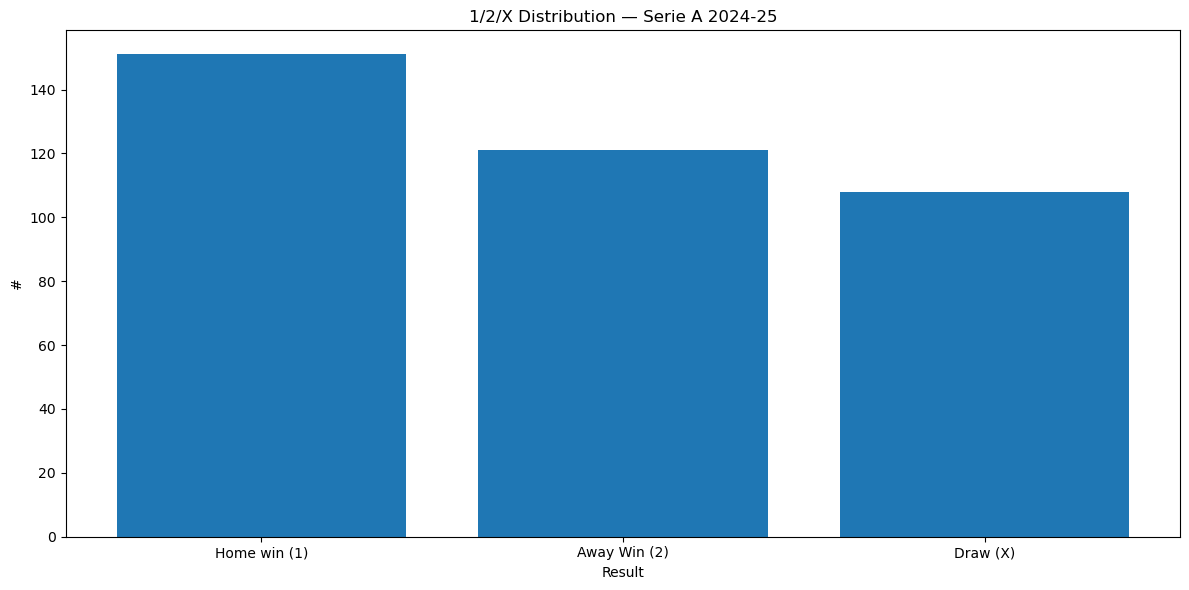

In [177]:
# Result (1/2/X) percentage
result = df.FTR.value_counts(normalize = True)
print ("Result 1", round(result.H,3)*100,"%")
print ("Result 2", round(result.A,3)*100,"%")
print ("Result X", round(result.D,3)*100,"%")

result = df.FTR.value_counts()
plt.figure(figsize=(12, 6))
plt.bar(result.index, result.values)
plt.title("1/2/X Distribution — Serie A 2024-25")
plt.xlabel("Result")
plt.ylabel("#")
plt.xticks([0, 1, 2], ['Home win (1)', 'Away Win (2)', 'Draw (X)'])
plt.tight_layout()
plt.savefig("distribuzione_risulati.png")
plt.show()

## 5. Most frequent exact scores

In [150]:
# More frequent results
results = (df.FTHG.astype(str) + " - " + df.FTAG.astype(str))
print("Most frequent results:\n", results.value_counts().head(3))

Most frequent results:
 1 - 1    53
1 - 0    38
2 - 1    36
Name: count, dtype: int64


## 6. Matches with at least one team scoreless

In [178]:
# Matches with at least one team @0 gols
print("Matches with at least one team @0 gols:", ((df.FTHG == 0) | (df.FTAG == 0)).sum(), "(",round((((df.FTHG == 0) | (df.FTAG == 0)).sum())/tot_matches*100,2),"%)")


Matches with at least one team @0 gols: 184 ( 48.42 %)


## 7. Total goals distribution per match

In [179]:
df = df.copy()
df["total_gol"] = df.FTHG + df.FTAG
df["total_gol"].value_counts().sort_index()

total_gol
0    28
1    71
2    98
3    84
4    53
5    37
6     7
7     1
8     1
Name: count, dtype: int64

## 8. Team with most draws

In [180]:
# calculating total draws per each team
total_draw = {}
for team in teams:
    home_draw = ((df.HomeTeam == team) & (df.FTR == "D")).sum()
    away_draw = ((df.AwayTeam == team) & (df.FTR == "D")).sum()
    total_draw[team] = int(home_draw + away_draw)
draw_series = pd.Series(total_draw)
print ("Team that has drawn the most: ", draw_series.idxmax()," - ", draw_series.max())


Team that has drawn the most:  Juventus  -  16


## 9. Wins per team

In [181]:
# calculating total wins per each team
total_win = {}
for team in teams:
    home_win = ((df.HomeTeam == team) & (df.FTR == "H")).sum()
    away_win = ((df.AwayTeam == team) & (df.FTR == "A")).sum()
    total_win[team] = int(home_win + away_win)
total_win

{'Genoa': 10,
 'Parma': 7,
 'Empoli': 6,
 'Milan': 18,
 'Bologna': 16,
 'Verona': 10,
 'Cagliari': 9,
 'Lazio': 18,
 'Lecce': 8,
 'Juventus': 18,
 'Udinese': 12,
 'Inter': 24,
 'Monza': 3,
 'Fiorentina': 19,
 'Torino': 10,
 'Napoli': 24,
 'Roma': 20,
 'Venezia': 5,
 'Como': 13,
 'Atalanta': 22}